# Demo I — monitoring window, alert policy and threshold (`demo-v1`)

Final Demo I evaluation for the dashboard model: **LightGBM `no_dc`** of run `aki_ml_v1_28e0b1fb83`, **Platt**
calibration, alerts on the **24h** horizon (6/12/48h displayed only). This replaces the quick `demo-v0` check
(threshold chosen and judged on validation alone).

**Data roles**
- *Selection*: out-of-fold (OOF) predictions of the training patients (5 patient-level folds from notebook 02).
  Every choice below - monitoring window, policy, threshold - is made here.
- *Confirmation*: validation patients, used once on the locked choice (with patient-level bootstrap CIs).
  Validation was already viewed in `demo-v0`, so it is a confirmation set, not a pristine one.
- *Test*: not loaded. It stays untouched for one final evaluation of the locked system.

**Rules fixed before looking at results**
1. *Monitoring window.* Segments of ICU hours 1-3, 4-6, 7-12, 13-18, 19-24, 25-36, 37-48, 49-60, 61-72. A segment
   is reliable for 24h alerts when AUROC >= 0.75, calibration slope in [0.8, 1.25], observed/expected in
   [0.8, 1.25], and >= 100 positive rows. The window is the longest contiguous run of reliable segments (ties: earlier).
2. *Alert policies* (risk >= threshold as the base): sustained for 1, 2 or 3 consecutive hours; repeat-alert
   cooldown 6, 12 or 24 h; with or without a rising-risk filter (risk >= 1.5 x the minimum of the prior 12 h).
   18 policies x thresholds 0.02-0.60 (step 0.01). Simulated on every hourly prediction in the window.
3. *Operating point.* Maximise AKI event detection subject to alert PPV >= 1/3 (at most two false alerts per
   correct alert, the operating point used by Tomasev et al., Nature 2019), median lead time >= 6 h, and
   <= 1 alert per patient-day. Within 0.5 percentage points of the best detection, prefer fewer alerts per
   patient-day, then the simpler policy, then the higher threshold. Other PPV floors are shown as sensitivity.

Alert definitions are in `src/aki_ml/alerts.py`. Outputs: `artifacts/demo_i/` (local, gitignored). Aggregates only.

In [1]:
import hashlib
import json
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / "configs" / "ml.yaml").exists() and (path / "pipeline").exists():
            return path
    raise FileNotFoundError("Run this notebook from inside the AIForHealth-AKIEarlyWarning repository.")


REPO_ROOT = find_repo_root()
sys.path.insert(0, str(REPO_ROOT / "src"))
from aki_ml import logit
from aki_ml import alerts as al

CFG = {
    "policy_version": "demo-v1",
    "run_id": "aki_ml_v1_28e0b1fb83",
    "family": "lightgbm",
    "feature_set": "no_dc",
    "calibration": "platt",
    "alert_horizon_h": 24,
    "horizons_h": [6, 12, 24, 48],
    "segments": [(1, 3), (4, 6), (7, 12), (13, 18), (19, 24), (25, 36), (37, 48), (49, 60), (61, 72)],
    "min_auroc": 0.75, "slope_range": (0.8, 1.25), "oe_range": (0.8, 1.25), "min_positives": 100,
    "sustain_hours": [1, 2, 3], "cooldown_hours": [6, 12, 24], "rise": [None, 1.5], "rise_window_hours": 12,
    "thresholds": np.round(np.arange(0.02, 0.605, 0.01), 2),
    "min_ppv": 1 / 3, "min_median_lead_h": 6.0, "max_alerts_per_day": 1.0,
    "ppv_sensitivity": [0.25, 1 / 3, 0.5],
    "comparison": ">=",
    "bootstrap": 1000, "seed": 20261007,
}
PRED_PATH = REPO_ROOT / "artifacts" / "predictions" / f"{CFG['run_id']}.parquet"
MODEL_DIR = REPO_ROOT / "artifacts" / "models" / CFG["run_id"] / f"{CFG['family']}__{CFG['feature_set']}"
OUT = REPO_ROOT / "artifacts" / "demo_i"
OUT.mkdir(parents=True, exist_ok=True)
RISK = f"risk_{CFG['calibration']}"
H = CFG["alert_horizon_h"]

## Part 1 — Load selection (train OOF) and confirmation (validation) predictions

In [2]:
def load(prediction_set, horizons):
    t = pq.read_table(PRED_PATH, filters=[("family", "=", CFG["family"]), ("feature_set", "=", CFG["feature_set"]),
                                          ("prediction_set", "=", prediction_set), ("horizon_h", "in", horizons)],
                      columns=["split", "horizon_h", "patient_id", "hours_since_icu", "snapshot_time",
                               "creatinine_aki_onset_time", "eligible", "label", "risk_platt", "risk_isotonic"])
    d = t.to_pandas()
    d["patient_id"] = d["patient_id"].astype(str)
    return d


sel = load("train_oof", [H])
val = load("validation", CFG["horizons_h"])
assert set(sel["split"]) == {"train"} and set(val["split"]) == {"validation"}, "test rows must never be loaded"
assert not set(sel["patient_id"]) & set(val["patient_id"])
for d in (sel, val):
    assert d[RISK].between(0, 1).all() and d["eligible"].eq(d["label"].notna()).all()
    assert not (d["creatinine_aki_onset_time"].notna() & (d["snapshot_time"] >= d["creatinine_aki_onset_time"])).any()
print(f"selection: {sel['patient_id'].nunique():,} train patients, {len(sel):,} hourly 24h predictions")
print(f"confirmation: {val['patient_id'].nunique():,} validation patients, {len(val[val.horizon_h == H]):,} hourly 24h predictions")

selection: 22,998 train patients, 938,762 hourly 24h predictions
confirmation: 4,950 validation patients, 198,524 hourly 24h predictions


## Part 2 — Monitoring window (selected on train OOF, confirmed on validation)

In [3]:
def calibration(y, p):
    lr = LogisticRegression(penalty=None, solver="lbfgs", max_iter=1000).fit(logit(p).reshape(-1, 1), y)
    return float(lr.coef_[0, 0]), float(lr.intercept_[0])


def segment_table(d):
    rows = []
    for lo, hi in CFG["segments"]:
        g = d[d["eligible"] & d["hours_since_icu"].between(lo, hi)]
        y, p = g["label"].to_numpy(int), g[RISK].to_numpy(np.float64)
        slope, intercept = calibration(y, p)
        rows.append({"segment": f"{lo}-{hi}h", "lo": lo, "hi": hi, "rows": len(y), "positives": int(y.sum()),
                     "prevalence": y.mean(), "auroc": roc_auc_score(y, p), "auprc": average_precision_score(y, p),
                     "cal_slope": slope, "cal_intercept": intercept, "obs_over_exp": y.mean() / p.mean()})
    t = pd.DataFrame(rows)
    t["reliable"] = ((t["auroc"] >= CFG["min_auroc"]) & t["cal_slope"].between(*CFG["slope_range"])
                     & t["obs_over_exp"].between(*CFG["oe_range"]) & (t["positives"] >= CFG["min_positives"]))
    return t


def longest_run(flags):
    best, start = (0, None), None
    for i, f in enumerate(list(flags) + [False]):
        if f and start is None:
            start = i
        if not f and start is not None:
            if i - start > best[0]:
                best = (i - start, start)
            start = None
    return best


seg_sel = segment_table(sel)
seg_val = segment_table(val[val["horizon_h"] == H])
length, first = longest_run(seg_sel["reliable"])
assert length > 0, "no reliable segment"
WINDOW = (int(seg_sel.loc[first, "lo"]), int(seg_sel.loc[first + length - 1, "hi"]))
seg = seg_sel.merge(seg_val, on=["segment", "lo", "hi"], suffixes=("_train_oof", "_validation"))
seg.to_csv(OUT / "window_segments.csv", index=False)
cols = ["segment"] + [f"{m}_{s}" for s in ("train_oof", "validation")
                      for m in ("positives", "auroc", "cal_slope", "obs_over_exp", "reliable")]
print(seg[cols].round(3).to_string(index=False))
print(f"\nMonitoring window (train OOF): ICU hours {WINDOW[0]}-{WINDOW[1]}")
in_win = seg_val["lo"].between(*WINDOW)
print("validation segments inside the window all reliable:", bool(seg_val.loc[in_win, "reliable"].all()))

segment  positives_train_oof  auroc_train_oof  cal_slope_train_oof  obs_over_exp_train_oof  reliable_train_oof  positives_validation  auroc_validation  cal_slope_validation  obs_over_exp_validation  reliable_validation
   1-3h                 4476            0.754                0.833                   0.861                True                   993             0.745                 0.786                    0.901                False
   4-6h                 6210            0.766                0.871                   0.880                True                  1391             0.777                 0.910                    0.900                 True
  7-12h                12148            0.780                0.926                   0.917                True                  2822             0.793                 0.973                    0.962                 True
 13-18h                10932            0.803                1.009                   0.990                True              

## Part 3 — Alert policy and threshold (selected on train OOF)

In [4]:
POLICIES = [al.Policy(s, c, r, CFG["rise_window_hours"])
            for s in CFG["sustain_hours"] for c in CFG["cooldown_hours"] for r in CFG["rise"]]


def alert_frame(d):
    d = d[(d["horizon_h"] == H) & d["hours_since_icu"].between(*WINDOW)].rename(columns={RISK: "risk"})
    d = al.prepare(d, H)
    d["prior_min"] = al.prior_min(d, CFG["rise_window_hours"])
    return d


sel_a = alert_frame(sel)
t0 = time.time()
res = al.grid(sel_a, CFG["thresholds"], POLICIES, CFG["comparison"])
res.to_csv(OUT / "policy_grid_train_oof.csv", index=False)
print(f"{len(POLICIES)} policies x {len(CFG['thresholds'])} thresholds in {(time.time() - t0) / 60:.1f} min")

choice = al.select(res, min_ppv=CFG["min_ppv"], max_alerts_per_day=CFG["max_alerts_per_day"],
                   min_median_lead_h=CFG["min_median_lead_h"])
assert choice is not None, "no policy meets the prespecified constraints"
POLICY = al.Policy(int(choice["sustain_hours"]), float(choice["cooldown_hours"]),
                   float(choice["rise_ratio"]) or None, CFG["rise_window_hours"])
THRESHOLD = float(choice["threshold"])
show = ["policy", "threshold", "event_detection_rate", "alert_ppv", "alerts_per_patient_day",
        "false_alerts_per_patient_day", "lead_time_median_h", "non_aki_patients_alerted"]

# Best operating point of each policy under the same constraints (how much the policy choice matters).
per_policy = pd.DataFrame([al.select(g, min_ppv=CFG["min_ppv"], max_alerts_per_day=CFG["max_alerts_per_day"],
                                     min_median_lead_h=CFG["min_median_lead_h"])
                           for _, g in res.groupby("policy", sort=False)]).dropna(how="all")
print(per_policy[show].sort_values("event_detection_rate", ascending=False).round(3).to_string(index=False))
print(f"\nSelected: {POLICY.name}; 24h risk {CFG['comparison']} {THRESHOLD}")

18 policies x 59 thresholds in 4.4 min
                                 policy  threshold  event_detection_rate  alert_ppv  alerts_per_patient_day  false_alerts_per_patient_day  lead_time_median_h  non_aki_patients_alerted
                sustain 1h, cooldown 6h       0.21                 0.732      0.336                   0.772                         0.401              13.424                     0.359
                sustain 2h, cooldown 6h       0.19                 0.716      0.336                   0.759                         0.390              13.029                     0.352
                sustain 3h, cooldown 6h       0.18                 0.694      0.338                   0.729                         0.371              12.748                     0.338
               sustain 1h, cooldown 12h       0.24                 0.682      0.342                   0.404                         0.212              12.386                     0.302
               sustain 2h, cooldown 12h  

In [5]:
# Sensitivity of the operating point to the PPV floor (selection data).
sens = []
for floor in CFG["ppv_sensitivity"]:
    c = al.select(res, min_ppv=floor, max_alerts_per_day=CFG["max_alerts_per_day"],
                  min_median_lead_h=CFG["min_median_lead_h"])
    if c is not None:
        sens.append({"ppv_floor": round(floor, 3), **c[show].to_dict()})
sens = pd.DataFrame(sens)
sens.to_csv(OUT / "ppv_floor_sensitivity_train_oof.csv", index=False)
print(sens.round(3).to_string(index=False))

 ppv_floor                   policy  threshold  event_detection_rate  alert_ppv  alerts_per_patient_day  false_alerts_per_patient_day  lead_time_median_h  non_aki_patients_alerted
     0.250 sustain 1h, cooldown 12h       0.14                 0.834      0.254                   0.735                         0.419              13.089                     0.519
     0.333  sustain 1h, cooldown 6h       0.21                 0.732      0.336                   0.772                         0.401              13.424                     0.359
     0.500  sustain 1h, cooldown 6h       0.41                 0.421      0.507                   0.233                         0.096              10.793                     0.111


## Part 4 — Confirmation on validation (locked window, policy and threshold)

One evaluation of the locked choice; 95% CIs from 1,000 patient-level bootstrap resamples. `demo-v0`
(risk >= 0.085, 12 h cooldown, hours 1-72, chosen on validation) is shown for comparison under the same
deployment-like simulation.

In [6]:
val_a = alert_frame(val)
pp = al.per_patient(val_a, al.policy_alerts(val_a, THRESHOLD, POLICY, CFG["comparison"]))
point = pd.Series(al.summarize(pp), name="demo-v1")
ci = al.bootstrap(pp, CFG["bootstrap"], CFG["seed"])
v0_rows = al.prepare(val[val["horizon_h"] == H].rename(columns={RISK: "risk"}), H)
v0 = pd.Series(al.evaluate(v0_rows, 0.085, al.Policy(1, 12)), name="demo-v0 (validation-chosen)")
sel_point = pd.Series(choice[point.index].astype(float), name="demo-v1 on train OOF")
confirm = pd.concat([sel_point, point, ci, v0], axis=1)
confirm.to_csv(OUT / "policy_confirmation_validation.csv")
print(confirm.round(3).to_string())

                                   demo-v1 on train OOF   demo-v1    ci_low   ci_high  demo-v0 (validation-chosen)
patient_days                                  39115.083  8271.833  8143.664  8395.875                     8271.833
alerts_per_patient_day                            0.772     0.818     0.785     0.851                        1.113
false_alerts_per_patient_day                      0.401     0.427     0.403     0.451                        0.648
unlabelled_alerts_per_patient_day                 0.168     0.173     0.159     0.188                        0.292
alert_ppv                                         0.336     0.338     0.318     0.359                        0.210
aki_events                                     4373.000   965.000   912.000  1015.025                      965.000
event_detection_rate                              0.732     0.762     0.735     0.788                        0.935
lead_time_median_h                               13.424    12.680    11.833    1

In [7]:
# Discrimination and calibration on validation: all horizons, whole 1-72 h grid and inside the window,
# Platt (primary) and isotonic (sensitivity). AUROC CI for the 24h window from a patient-level bootstrap.
rng = np.random.default_rng(CFG["seed"])
disc = []
for h in CFG["horizons_h"]:
    for scope, d in [("hours 1-72", val), (f"window {WINDOW[0]}-{WINDOW[1]}h", val[val["hours_since_icu"].between(*WINDOW)])]:
        g = d[(d["horizon_h"] == h) & d["eligible"]]
        y = g["label"].to_numpy(int)
        for cal in ["platt", "isotonic"]:
            p = g[f"risk_{cal}"].to_numpy(np.float64)
            slope, intercept = calibration(y, p)
            disc.append({"horizon_h": h, "scope": scope, "calibration": cal, "rows": len(y), "prevalence": y.mean(),
                         "auroc": roc_auc_score(y, p), "auprc": average_precision_score(y, p),
                         "brier": brier_score_loss(y, p), "cal_slope": slope, "cal_intercept": intercept})
disc = pd.DataFrame(disc)

g = val[(val["horizon_h"] == H) & val["eligible"] & val["hours_since_icu"].between(*WINDOW)]
pids = g["patient_id"].unique()
by_pid = {k: v.index.to_numpy() for k, v in g.groupby("patient_id")}
y_all, p_all = g["label"].to_numpy(int), g[RISK].to_numpy(np.float64)
pos = {k: i for i, k in enumerate(g.index)}
boot = []
for _ in range(200):
    rows = np.concatenate([by_pid[k] for k in rng.choice(pids, len(pids))])
    ix = np.fromiter((pos[r] for r in rows), int, len(rows))
    boot.append(roc_auc_score(y_all[ix], p_all[ix]))
AUROC_CI = tuple(np.percentile(boot, [2.5, 97.5]))
disc.to_csv(OUT / "validation_discrimination.csv", index=False)
print(disc[disc["calibration"] == "platt"].drop(columns="calibration").round(4).to_string(index=False))
print(f"\n24h AUROC in window, validation: {roc_auc_score(y_all, p_all):.3f} (95% CI {AUROC_CI[0]:.3f}-{AUROC_CI[1]:.3f})")

 horizon_h        scope   rows  prevalence  auroc  auprc  brier  cal_slope  cal_intercept
         6   hours 1-72 180443      0.0293 0.8648 0.2112 0.0254     1.0138         0.0465
         6 window 1-72h 180443      0.0293 0.8648 0.2112 0.0254     1.0138         0.0465
        12   hours 1-72 162191      0.0605 0.8394 0.3052 0.0486     1.0318         0.0864
        12 window 1-72h 162191      0.0605 0.8394 0.3052 0.0486     1.0318         0.0864
        24   hours 1-72 129215      0.1258 0.8089 0.4224 0.0901     1.0279         0.0584
        24 window 1-72h 129215      0.1258 0.8089 0.4224 0.0901     1.0279         0.0584
        48   hours 1-72  90500      0.2559 0.7820 0.5677 0.1513     1.0143         0.0204
        48 window 1-72h  90500      0.2559 0.7820 0.5677 0.1513     1.0143         0.0204

24h AUROC in window, validation: 0.809 (95% CI 0.796-0.823)


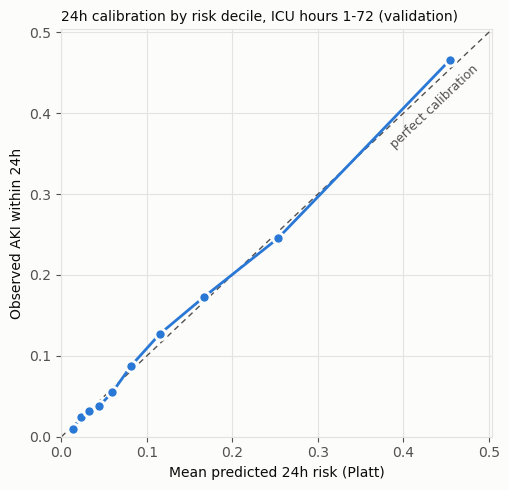

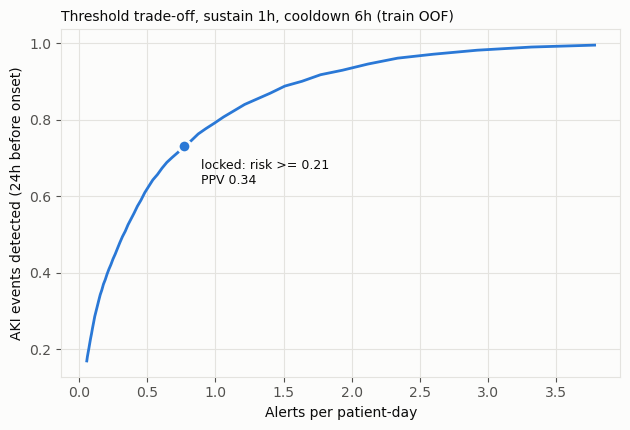

In [8]:
# Figures: 24h calibration in the window (validation) and the detection / alert-burden trade-off of the
# selected policy across thresholds (train OOF), with the locked threshold marked.
INK, MUTED, GRID, SURFACE, SERIES = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb", "#2a78d6"


def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, lw=0.8)
    for s in ax.spines.values():
        s.set_color(GRID)
    ax.tick_params(colors=MUTED)


cal = g.groupby(pd.qcut(g[RISK], 10, duplicates="drop"), observed=True).agg(predicted=(RISK, "mean"), observed=("label", "mean"))
cal.to_csv(OUT / "calibration_24h_validation.csv")
fig, ax = plt.subplots(figsize=(5.2, 5), facecolor=SURFACE)
style(ax)
top = float(max(cal["predicted"].max(), cal["observed"].max()) * 1.08)
ax.plot([0, top], [0, top], color=MUTED, lw=1, ls=(0, (4, 3)))
ax.text(top * 0.97, top * 0.90, "perfect calibration", color=MUTED, fontsize=9, ha="right", rotation=45,
        rotation_mode="anchor", transform_rotates_text=True)
ax.plot(cal["predicted"], cal["observed"], color=SERIES, lw=2, marker="o", ms=8, mec=SURFACE, mew=2)
ax.set_xlim(0, top), ax.set_ylim(0, top)
ax.set_xlabel("Mean predicted 24h risk (Platt)", color=INK)
ax.set_ylabel("Observed AKI within 24h", color=INK)
ax.set_title(f"24h calibration by risk decile, ICU hours {WINDOW[0]}-{WINDOW[1]} (validation)",
             color=INK, fontsize=10, loc="left")
fig.tight_layout()
fig.savefig(OUT / "calibration_24h_validation.png", dpi=150, facecolor=SURFACE)
plt.show()

curve = res[res["policy"] == POLICY.name].sort_values("threshold")
fig, ax = plt.subplots(figsize=(6.4, 4.4), facecolor=SURFACE)
style(ax)
ax.plot(curve["alerts_per_patient_day"], curve["event_detection_rate"], color=SERIES, lw=2)
ax.plot([choice["alerts_per_patient_day"]], [choice["event_detection_rate"]], "o", color=SERIES, ms=9, mec=SURFACE, mew=2)
ax.annotate(f"locked: risk >= {THRESHOLD:.2f}\nPPV {choice['alert_ppv']:.2f}", (choice["alerts_per_patient_day"],
            choice["event_detection_rate"]), xytext=(12, -28), textcoords="offset points", color=INK, fontsize=9)
ax.set_xlabel("Alerts per patient-day", color=INK)
ax.set_ylabel("AKI events detected (24h before onset)", color=INK)
ax.set_title(f"Threshold trade-off, {POLICY.name} (train OOF)", color=INK, fontsize=10, loc="left")
fig.tight_layout()
fig.savefig(OUT / "threshold_tradeoff_train_oof.png", dpi=150, facecolor=SURFACE)
plt.show()

## Part 5 — Lock and write the policy

`policy.json` is read by `scripts/score_dashboard.py`: the threshold object (Data Contract v1) is attached to 24h
predictions inside the monitoring window only. The previous `demo-v0` file is kept as `policy_demo-v0.json`.

In [9]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


old = OUT / "policy.json"
if old.exists() and json.loads(old.read_text(encoding="utf-8")).get("policy_version") == "demo-v0":
    old.replace(OUT / "policy_demo-v0.json")

window_text = f"ICU hours {WINDOW[0]}-{WINDOW[1]}"
basis = (f"Selected on out-of-fold predictions of training patients (run {CFG['run_id']}); confirmed once on "
         f"validation. Window: longest run of ICU-hour segments with AUROC >= {CFG['min_auroc']}, calibration slope "
         f"and O/E within [0.8, 1.25]. Policy ({POLICY.name}) and threshold: highest AKI event detection with alert "
         f"PPV >= 1/3, median lead >= {CFG['min_median_lead_h']:g} h and <= {CFG['max_alerts_per_day']:g} alert per "
         f"patient-day. Validation: detection {point['event_detection_rate']:.3f}, PPV {point['alert_ppv']:.3f}, "
         f"{point['alerts_per_patient_day']:.3f} alerts/patient-day, median lead {point['lead_time_median_h']:.1f} h. "
         f"Demo setting, not a clinical threshold; test set not evaluated.")
assert len(basis) <= 2000
policy = {
    "policy_version": CFG["policy_version"],
    "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model": {"run_id": CFG["run_id"], "family": CFG["family"], "feature_set": CFG["feature_set"],
              "model_dir": str(MODEL_DIR.relative_to(REPO_ROOT)).replace("\\", "/"),
              "pipeline_sha256": sha256(MODEL_DIR / "pipeline.joblib"),
              "feature_order_sha256": sha256(MODEL_DIR / "feature_order.json")},
    "alert_horizon_h": H,
    "display_horizons_h": [h for h in CFG["horizons_h"] if h != H],
    "monitoring_hours": list(WINDOW),
    "alert_policy": {"rule": "risk >= threshold", "sustain_hours": POLICY.sustain_hours,
                     "cooldown_hours": POLICY.cooldown_hours, "rise_ratio": POLICY.rise_ratio,
                     "rise_window_hours": POLICY.rise_window_hours},
    "threshold": {"value": THRESHOLD, "comparison": CFG["comparison"],
                  "validation_run_id": f"{CFG['run_id']}/train_oof-selected/validation-confirmed",
                  "policy_version": CFG["policy_version"], "monitoring_window": window_text,
                  "calibration_version": f"{CFG['calibration']} (fit on train OOF, {CFG['run_id']})",
                  "locked": True, "selection_basis": basis},
    "selection_metrics_train_oof": {k: float(choice[k]) for k in point.index},
    "validation_metrics": {k: float(v) for k, v in point.items()},
    "validation_ci95": {k: [float(a), float(b)] for k, (a, b) in ci.iterrows()},
    "validation_auroc_24h_window": [float(roc_auc_score(y_all, p_all)), *map(float, AUROC_CI)],
    "test_set_used": False,
}
(OUT / "policy.json").write_text(json.dumps(policy, indent=2), encoding="utf-8")
print(json.dumps({k: policy[k] for k in ["monitoring_hours", "alert_policy"]}, indent=1))
print(json.dumps(policy["threshold"], indent=1))

{
 "monitoring_hours": [
  1,
  72
 ],
 "alert_policy": {
  "rule": "risk >= threshold",
  "sustain_hours": 1,
  "cooldown_hours": 6.0,
  "rise_ratio": null,
  "rise_window_hours": 12
 }
}
{
 "value": 0.21,
 "comparison": ">=",
 "validation_run_id": "aki_ml_v1_28e0b1fb83/train_oof-selected/validation-confirmed",
 "policy_version": "demo-v1",
 "monitoring_window": "ICU hours 1-72",
 "calibration_version": "platt (fit on train OOF, aki_ml_v1_28e0b1fb83)",
 "locked": true,
 "selection_basis": "Selected on out-of-fold predictions of training patients (run aki_ml_v1_28e0b1fb83); confirmed once on validation. Window: longest run of ICU-hour segments with AUROC >= 0.75, calibration slope and O/E within [0.8, 1.25]. Policy (sustain 1h, cooldown 6h) and threshold: highest AKI event detection with alert PPV >= 1/3, median lead >= 6 h and <= 1 alert per patient-day. Validation: detection 0.762, PPV 0.338, 0.818 alerts/patient-day, median lead 12.7 h. Demo setting, not a clinical threshold; test s